In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# Descargar precios de MELI
meli = yf.download('MELI', start='2018-01-01')
fechas = meli.index
meli_precios = meli['Close']['MELI']
tiempo = np.arange(len(fechas))

[*********************100%***********************]  1 of 1 completed


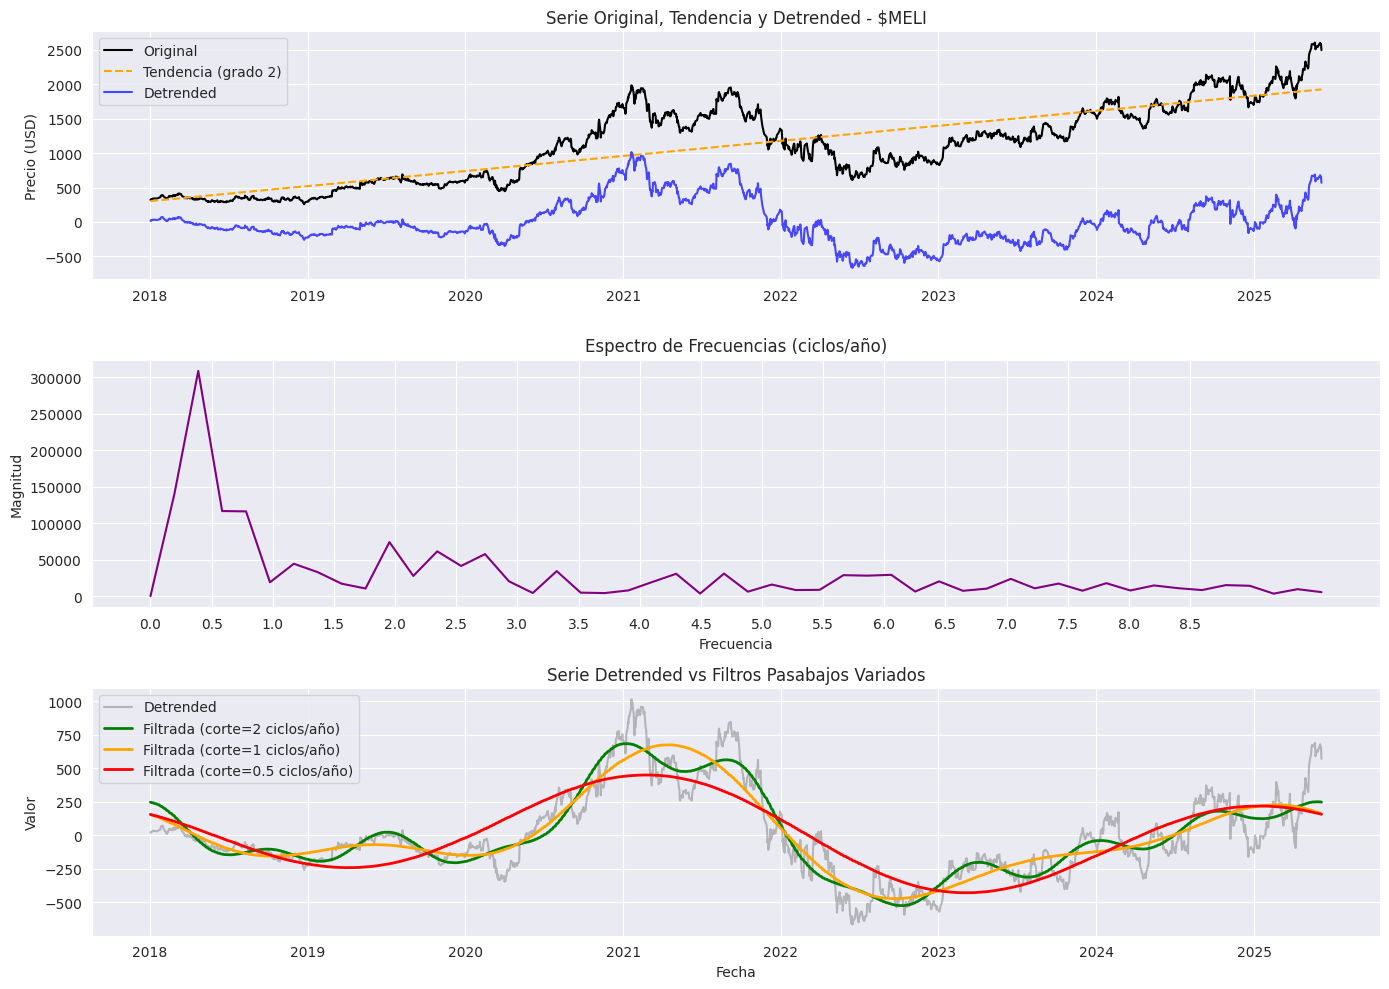

In [16]:
# --- Detrending polinomial ---
grado = 1 # 1 para lineal, si se extiene tiempo (ej 2015 - 2025) es mejor grado 2
coeficientes = np.polyfit(tiempo, meli_precios, grado)
tendencia = np.polyval(coeficientes, tiempo)
detrended = meli_precios - tendencia

# --- FFT ---
fft_detrended = np.fft.fft(detrended)
frecuencias = np.fft.fftfreq(len(detrended), d=1)
frecuencias_ciclos_por_ano = frecuencias * 365
magnitudes = np.abs(fft_detrended)

# Filtramos solo frecuencias positivas
N = len(detrended)
frecuencias_pos = frecuencias_ciclos_por_ano[:N//2]
magnitudes_pos = magnitudes[:N//2]
limite_frecuencias_bajas = 50

# --- Filtros pasabajos con diferentes cortes ---
cortes = [2, 1, 0.5]
colores = ['green', 'orange', 'red']
series_filtradas = []

for corte in cortes:
    fft_temp = fft_detrended.copy()
    fft_temp[np.abs(frecuencias_ciclos_por_ano) > corte] = 0
    serie_temp = np.fft.ifft(fft_temp).real
    series_filtradas.append(serie_temp)

# --- Graficar todo en subplots ---
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

# 1. Serie original, tendencia y detrended
axs[0].plot(fechas, meli_precios, label='Original', color='black')
axs[0].plot(fechas, tendencia, label='Tendencia (grado 2)', linestyle='--', color='orange')
axs[0].plot(fechas, detrended, label='Detrended', alpha=0.7, color='blue')
axs[0].set_title('Serie Original, Tendencia y Detrended - $MELI')
axs[0].set_ylabel('Precio (USD)')
axs[0].legend()
axs[0].grid(True)

# 2. Espectro de frecuencias
axs[1].plot(frecuencias_pos[:limite_frecuencias_bajas], magnitudes_pos[:limite_frecuencias_bajas], color='purple')
axs[1].set_title('Espectro de Frecuencias (ciclos/año)')
axs[1].set_xlabel('Frecuencia')
axs[1].set_ylabel('Magnitud')
axs[1].set_xticks(np.arange(0, 9, 0.5))
axs[1].grid(True)

# 3. Serie detrended vs varias filtradas
axs[2].plot(fechas, detrended, label='Detrended', alpha=0.5, color='gray')
for corte, color, serie_filtrada in zip(cortes, colores, series_filtradas):
    axs[2].plot(fechas, serie_filtrada, label=f'Filtrada (corte={corte} ciclos/año)', color=color, linewidth=2)
axs[2].set_title('Serie Detrended vs Filtros Pasabajos Variados')
axs[2].set_xlabel('Fecha')
axs[2].set_ylabel('Valor')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()
